# Automatic Differentiation with Distributions

All ProbPipe distributions are JAX-native, which means `jax.grad`, `jax.value_and_grad`, and `jax.jacobian` work out of the box on `_log_prob`, `_prob`, and any function that uses them. This notebook covers:

1. **Differentiating log-densities** — gradients of `_log_prob` w.r.t. inputs and parameters
2. **Sensitivity analysis** — how distribution parameters affect downstream computations
3. **Gradient-based optimization** — maximum likelihood estimation
4. **Variational inference** — fitting an approximate posterior by minimizing KL divergence

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal, MultivariateNormal, Beta, Gamma,
    EmpiricalDistribution, TransformedDistribution,
    ProductDistribution,
)

key = jax.random.PRNGKey(0)

## 1. Differentiating Log-Densities

The gradient of `_log_prob(x)` w.r.t. `x` is the **score function** — a fundamental quantity in statistics and machine learning. For a Normal distribution, $\nabla_x \log p(x) = -(x - \mu)/\sigma^2$.

In [2]:
n = Normal(loc=2.0, scale=0.5, name="auto_d1")

# Gradient of log_prob w.r.t. x (the score function)
score_fn = jax.grad(n._log_prob)

x = jnp.array(3.0)
score = score_fn(x)
analytical = -(x - 2.0) / 0.5**2  # -(x - mu) / sigma^2

print(f'Score at x={float(x)}: {float(score):.4f}')
print(f'Analytical:          {float(analytical):.4f}')
print(f'Match: {bool(jnp.isclose(score, analytical))}')

Score at x=3.0: -4.0000
Analytical:          -4.0000
Match: True


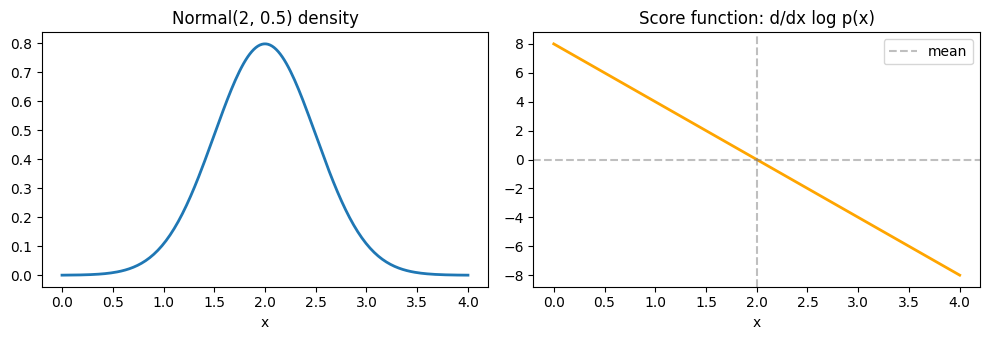

In [3]:
# Vectorize: score function over a grid
xs = jnp.linspace(0.0, 4.0, 200)
scores = jax.vmap(score_fn)(xs)
log_probs = jax.vmap(n._log_prob)(xs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(xs, jnp.exp(log_probs), linewidth=2)
ax1.set_title('Normal(2, 0.5) density')
ax1.set_xlabel('x')

ax2.plot(xs, scores, linewidth=2, color='orange')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(2.0, color='gray', linestyle='--', alpha=0.5, label='mean')
ax2.set_title('Score function: d/dx log p(x)')
ax2.set_xlabel('x')
ax2.legend()
plt.tight_layout()
plt.show()

### Multivariate Gradients

Gradients work the same way with multivariate distributions.

In [4]:
mvn = MultivariateNormal(
    loc=jnp.array([1.0, 2.0]),
    cov=jnp.array([[1.0, 0.5], [0.5, 1.0]]), name="auto_d1"
)

x = jnp.array([1.5, 2.5])
grad_lp = jax.grad(mvn._log_prob)(x)
print(f'x = {x}')
print(f'grad log_prob = {grad_lp}')
print(f'(Points toward the mean — higher density region)')

x = [1.5 2.5]
grad log_prob = [-0.33333334 -0.3333333 ]
(Points toward the mean — higher density region)


### Joint Distribution Gradients

`ProductDistribution` is registered as a JAX pytree, so its `_log_prob` is fully differentiable. The gradient is the concatenation of per-component score functions.

In [5]:
joint = ProductDistribution(
    mu=Normal(loc=0.0, scale=1.0, name="auto_d2"),
    sigma=Normal(loc=1.0, scale=0.5, name="auto_d3"),
)

# Use as_flat_distribution() so _log_prob accepts a flat vector
# (ProductDistribution._log_prob expects a dict, not an array)
flat_joint = joint.as_flat_distribution()

x = jnp.array([0.5, 1.2])  # [mu_val, sigma_val]
grad_joint = jax.grad(flat_joint._log_prob)(x)
print(f'x = {x}')
print(f'grad log_prob = {grad_joint}')
print(f'  d/d(mu)    = {float(grad_joint[0]):.4f}  (analytical: {float(-0.5):.4f})')
print(f'  d/d(sigma) = {float(grad_joint[1]):.4f}  (analytical: {float(-(1.2-1.0)/0.25):.4f})')

x = [0.5 1.2]
grad log_prob = [-0.5       -0.8000002]
  d/d(mu)    = -0.5000  (analytical: -0.5000)
  d/d(sigma) = -0.8000  (analytical: -0.8000)


## 2. Sensitivity Analysis

We can use `jax.grad` to understand how a function's output depends on the **parameters** of an input distribution. For example: how does the expected loss change as the prior location shifts?

In [6]:
# Quadratic loss as a function of prior location
# E[x^2] where x ~ Normal(loc, 1, name="auto_d2") = loc^2 + 1
def expected_quadratic_loss(loc):
    """Monte Carlo estimate of E[x^2] where x ~ Normal(loc, 1)."""
    dist = Normal(loc=loc, scale=1.0, name="auto_d4")
    # Use _sample directly (not the ops `sample`) so JAX can trace through
    samples = dist._sample(key=jax.random.PRNGKey(42), sample_shape=(5000,))
    return jnp.mean(samples ** 2)

# Gradient: d/d(loc) E[x^2] = 2*loc (analytically)
# Note: this differentiates through the reparameterization trick
loc_val = jnp.array(3.0)
loss, grad_loss = jax.value_and_grad(expected_quadratic_loss)(loc_val)
print(f'loc = {float(loc_val)}')
print(f'E[x^2] = {float(loss):.3f} (analytical: {float(loc_val**2 + 1):.1f})')
print(f'd/d(loc) E[x^2] = {float(grad_loss):.3f} (analytical: {float(2*loc_val):.1f})')

loc = 3.0
E[x^2] = 9.878 (analytical: 10.0)
d/d(loc) E[x^2] = 5.963 (analytical: 6.0)


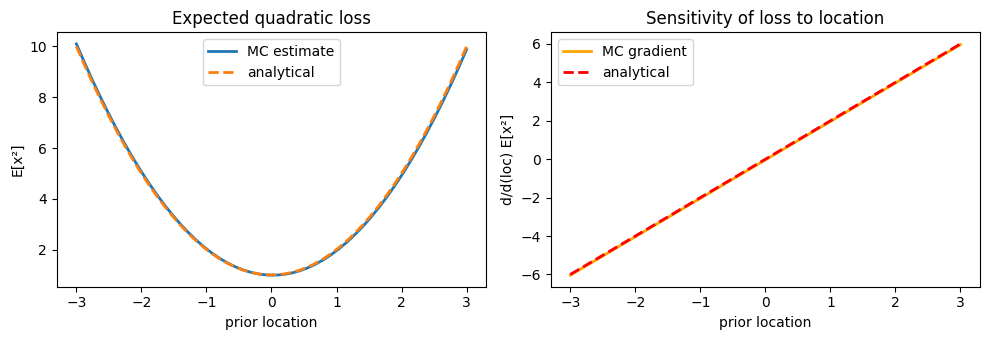

In [7]:
# Sensitivity across a range of locations
locs = jnp.linspace(-3.0, 3.0, 50)
losses = jax.vmap(expected_quadratic_loss)(locs)
grads = jax.vmap(jax.grad(expected_quadratic_loss))(locs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(locs, losses, linewidth=2, label='MC estimate')
ax1.plot(locs, locs**2 + 1, '--', linewidth=2, label='analytical')
ax1.set_xlabel('prior location')
ax1.set_ylabel('E[x²]')
ax1.set_title('Expected quadratic loss')
ax1.legend()

ax2.plot(locs, grads, linewidth=2, color='orange', label='MC gradient')
ax2.plot(locs, 2*locs, '--', linewidth=2, color='red', label='analytical')
ax2.set_xlabel('prior location')
ax2.set_ylabel('d/d(loc) E[x²]')
ax2.set_title('Sensitivity of loss to location')
ax2.legend()
plt.tight_layout()
plt.show()

## 3. Maximum Likelihood Estimation

Given observed data, find the parameters that maximize the log-likelihood using gradient ascent.

In [8]:
# Generate synthetic data from a known distribution
true_loc, true_scale = 2.5, 0.8
data = jax.random.normal(jax.random.PRNGKey(1), (200,)) * true_scale + true_loc

# Negative log-likelihood as a function of (loc, log_scale)
# We optimize log_scale to keep scale positive without constraints
def neg_log_likelihood(params):
    loc, log_scale = params
    dist = Normal(loc=loc, scale=jnp.exp(log_scale), name="auto_d5")
    return -jnp.mean(jax.vmap(dist._log_prob)(data))

# Gradient descent
params = jnp.array([0.0, 0.0])  # start at loc=0, scale=1
lr = 0.1
history = []

for step in range(200):
    loss, grads = jax.value_and_grad(neg_log_likelihood)(params)
    params = params - lr * grads
    if step % 50 == 0 or step == 199:
        history.append((step, float(loss), float(params[0]), float(jnp.exp(params[1]))))

print(f'True:      loc={true_loc}, scale={true_scale}')
print(f'MLE:       loc={float(params[0]):.4f}, scale={float(jnp.exp(params[1])):.4f}')
print(f'Empirical: loc={float(jnp.mean(data)):.4f}, scale={float(jnp.std(data)):.4f}')
print(f'\nOptimization trace:')
for step, loss, loc, scale in history:
    print(f'  step {step:3d}: loss={loss:.4f}, loc={loc:.4f}, scale={scale:.4f}')

True:      loc=2.5, scale=0.8
MLE:       loc=2.6071, scale=0.8592
Empirical: loc=2.6071, scale=0.8592

Optimization trace:
  step   0: loss=4.6867, loc=0.2607, scale=1.9223
  step  50: loss=1.3312, loc=2.3434, scale=0.9836
  step 100: loss=1.2672, loc=2.6069, scale=0.8592
  step 150: loss=1.2672, loc=2.6071, scale=0.8592
  step 199: loss=1.2672, loc=2.6071, scale=0.8592


## 4. Variational Inference

Variational inference fits an approximate posterior $q_\phi(x)$ to a target $p(x)$ by minimizing the KL divergence, or equivalently maximizing the evidence lower bound (ELBO). Here we fit a Normal approximation to a non-Gaussian target.

In [9]:
# Target: mixture of two Gaussians (bimodal)
def target_log_prob(x):
    """Log-density of 0.3 * N(-2, 0.5) + 0.7 * N(2, 0.8)."""
    lp1 = Normal(loc=-2.0, scale=0.5, name="auto_d6")._log_prob(x) + jnp.log(0.3)
    lp2 = Normal(loc=2.0, scale=0.8, name="auto_d7")._log_prob(x) + jnp.log(0.7)
    return jnp.logaddexp(lp1, lp2)

# ELBO: E_q[log p(x) - log q(x)]
def elbo(params, key):
    loc, log_scale = params
    scale = jnp.exp(log_scale)
    # Reparameterize: x = loc + scale * eps, eps ~ N(0,1)
    eps = jax.random.normal(key, (500,))
    x = loc + scale * eps
    log_q = Normal(loc=loc, scale=scale, name="auto_d8")._log_prob(x)
    log_p = jax.vmap(target_log_prob)(x)
    return jnp.mean(log_p - log_q)

# Maximize ELBO via gradient ascent
params = jnp.array([0.0, 0.0])  # start at loc=0, scale=1
lr = 0.05
elbo_history = []

for step in range(300):
    step_key = jax.random.PRNGKey(step)
    val, grads = jax.value_and_grad(elbo)(params, step_key)
    params = params + lr * grads  # ascent (maximize ELBO)
    elbo_history.append(float(val))

fitted_loc = float(params[0])
fitted_scale = float(jnp.exp(params[1]))
print(f'Fitted q: Normal(loc={fitted_loc:.3f}, scale={fitted_scale:.3f})')
print(f'(Best unimodal fit to the bimodal target — should gravitate toward the dominant mode at 2.0)')

Fitted q: Normal(loc=2.003, scale=0.811)
(Best unimodal fit to the bimodal target — should gravitate toward the dominant mode at 2.0)


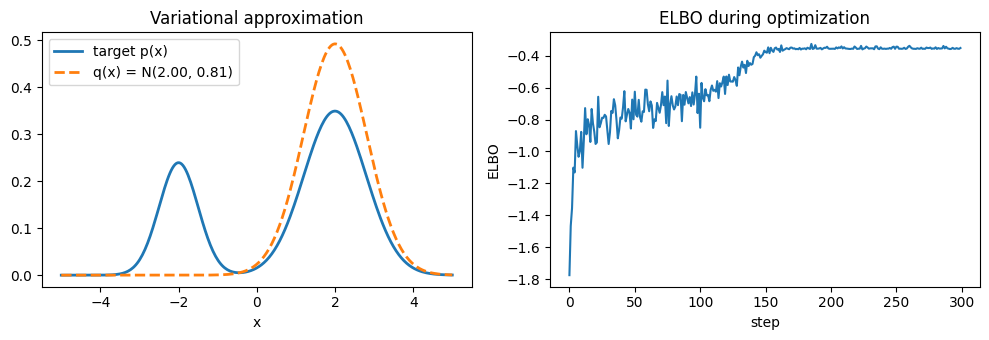

In [10]:
# Visualize
xs = jnp.linspace(-5.0, 5.0, 300)
target_density = jnp.exp(jax.vmap(target_log_prob)(xs))
q = Normal(loc=fitted_loc, scale=fitted_scale, name="auto_d9")
q_density = jax.vmap(lambda x: jnp.exp(q._log_prob(x)))(xs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.plot(xs, target_density, linewidth=2, label='target p(x)')
ax1.plot(xs, q_density, '--', linewidth=2, label=f'q(x) = N({fitted_loc:.2f}, {fitted_scale:.2f})')
ax1.set_title('Variational approximation')
ax1.set_xlabel('x')
ax1.legend()

ax2.plot(elbo_history, linewidth=1.5)
ax2.set_title('ELBO during optimization')
ax2.set_xlabel('step')
ax2.set_ylabel('ELBO')
plt.tight_layout()
plt.show()

## Summary

Key takeaways:

- ProbPipe distributions are **fully JAX-differentiable** — `jax.grad`, `jax.value_and_grad`, `jax.jacobian` all work on `_log_prob`, `_prob`, and any function that uses them.
- **Score functions** (gradients of log-density) are computed with a single `jax.grad` call.
- **Sensitivity analysis**: differentiate through sampling via the reparameterization trick to understand how distribution parameters affect downstream quantities.
- **Maximum likelihood**: optimize distribution parameters via gradient descent on the negative log-likelihood.
- **Variational inference**: maximize the ELBO to fit an approximate posterior, using reparameterized gradients.
- `ProductDistribution` is a registered JAX pytree, so joint `_log_prob` is differentiable end-to-end.